# Load libraries and set device up

In [16]:
import importlib
import libraries.graph as clg

try:
    cld = importlib.reload(cld)
except NameError:
    pass

try:
    clg = importlib.reload(clg)
except NameError:
    pass

In [17]:
import numpy as np
import torch.nn as nn
import os
import torch
from pathlib import Path
import importlib

import libraries.model as clm
import libraries.dataset as cld
import libraries.graph as clg

cld = importlib.reload(cld)
clg = importlib.reload(clg)

from torch_geometric.loader import DataLoader

# Checking if pytorch can run in GPU, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [18]:
import os
print(os.getcwd())

c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science


In [19]:
workspace_root = Path.cwd()
while not (workspace_root / 'input' / 'candidates').exists() and workspace_root.parent != workspace_root:
    workspace_root = workspace_root.parent

print(f"Using repository root: {workspace_root}")

folder = 'free-energies'

target_folder = workspace_root / f'models/{folder}'
data_root = workspace_root / 'input' / 'candidates'

Using repository root: c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science


In [20]:
from datetime import datetime

# Create timestamped folder for this model run
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
timestamped_folder = f'{target_folder}/results_{timestamp}'
os.makedirs(timestamped_folder, exist_ok=True)

print(f'Model results will be saved to: {timestamped_folder}')

Model results will be saved to: c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science\models\free-energies/results_20260427_194108


In [21]:
files_names = {
    # Reusable files (common for all models)
    'dataset':              f'{target_folder}/dataset.pt',
    'std_parameters':       f'{target_folder}/standardized_parameters.json',
    'dataset_parameters':   f'{target_folder}/dataset_parameters.json',
    
    # Model-specific files (unique per model run)
    'train_dataset_std':    f'{timestamped_folder}/train_dataset_std.pt',
    'val_dataset_std':      f'{timestamped_folder}/val_dataset_std.pt',
    'test_dataset_std':     f'{timestamped_folder}/test_dataset_std.pt',
    'model':                f'{timestamped_folder}/model.pt',
    'model_parameters':     f'{timestamped_folder}/model_parameters.json'
}
cld.save_json(files_names, f'{timestamped_folder}/files_names.json')

# Define parameters

In [ ]:
n_epochs =      50
batch_size =    128
learning_rate = 0.0001
dropout =       0.2
patience =      n_epochs
delta =         2
train_ratio =   0.8
val_ratio =     0.1
test_ratio =    0.1
max_samples =   None
targets = "3d" # Opciones: "3d" o "multitarget"

if targets == "3d":
    mis_targets = ['E_3D']
    # PyTorch Geometric creará un tensor 'y' de tamaño [1]
elif targets == "multitarget":
    mis_targets = ['E_1D', 'E_2D', 'E_3D']
    # PyTorch Geometric creará un tensor 'y' de tamaño [3]

model_parameters = {
    'n_epochs':      n_epochs,
    'batch_size':    batch_size,
    'learning_rate': learning_rate,
    'dropout':       dropout,
    'patience':      patience,
    'delta':         delta,
    'train_ratio':   train_ratio,
    'val_ratio':     val_ratio,
    'test_ratio':    test_ratio,
    'max_samples':   max_samples,
    'targets':       targets,
}
cld.save_json(model_parameters, files_names['model_parameters'])

# Generate or load graph database for training

In [23]:
# Try loading the training datasets directly, else generate them
# Generate data
cld.generate_dataset(str(data_root),
                        targets=mis_targets,
                        data_folder=str(target_folder),
                        max_samples=max_samples)

[generate_dataset] data_path=c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science\input\candidates, data_folder=c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science\models\free-energies, targets=['E_3D'], max_samples=None
Starting new dataset generation.
[generate_dataset] reloaded graph module: c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science\libraries\graph.py
Ba2Li(BO2)5
	P2_1-m
Ba2Li3La3(MoO4)8
	P1
Ba2Li3NbN4
	C2-c
Ba2Li3TaN4
	C2-c
Ba2Li3Y3(MoO4)8
	P1
Ba2LiAl(CN2)4
	P2_12_12_1
Ba2LiReN4
	P2_1-m
Ba2LiReO6
	Fm-3m
Ba3Li2V2Cl4O7
	C2-m
Ba3LiTa3Ti5O21
	Cmc2_1
Ba3LiTi5(SbO7)3
	Cmc2_1
	P1
Ba3LiTi5Nb3O21
	Cmc2_1
	P1
Ba4Li(BN2)3
	Im-3m
Ba4Li(BiO4)3
	Im-3m
Ba4Li(SbO4)3
	Im-3m
Ba4Li4Ti19O44
	P1
Ba4LiCu(CO5)2
	I-42m
Ba4LiGa5Se12
	P-42_1c
Ba4LiMo2N7
	P2-c
Ba4LiNb3O12
	P6_3mc
	Pnma
Ba4LiTa3O12
	P6_3mc
Ba4LiW2N7
	P2-c
Ba5Li2(TeO5)3
	I4-m
Ba5Li2(WO5)3
	P6_3mc
Ba5LiGaN3F5
	Pnma
Ba5LiMo2N7Cl2
	P2_1-

In [30]:
train_dataset[0]

Data(x=[22, 5], edge_index=[2, 3136], edge_attr=[3136], y=[1], label='Li2W2O7 P-1')

In [33]:
# Mostrar un ejemplo
data = train_dataset[0]
print(data)

# Detalles útiles
print("label:", data.label)
print("y:", data.y)
print("num_nodes:", data.num_nodes)
print("x.shape:", data.x.shape)
print("edge_index.shape:", data.edge_index.shape)
print("edge_attr.shape:", data.edge_attr.shape)

# Ver los primeros nodos y aristas
print("x[:5]:\n", data.x[:10])
print("edge_index[:, :20]:\n", data.edge_index[:, :20])
print("edge_attr[:20]:\n", data.edge_attr[:20])

Data(x=[22, 5], edge_index=[2, 3136], edge_attr=[3136], y=[1], label='Li2W2O7 P-1')
label: Li2W2O7 P-1
y: tensor([1.1328])
num_nodes: 22
x.shape: torch.Size([22, 5])
edge_index.shape: torch.Size([2, 3136])
edge_attr.shape: torch.Size([3136])
x[:5]:
 tensor([[  6.9410,   3.0000,   0.9800,   5.3900,   0.9000],
        [  6.9410,   3.0000,   0.9800,   5.3900,   0.9000],
        [  6.9410,   3.0000,   0.9800,   5.3900,   0.9000],
        [  6.9410,   3.0000,   0.9800,   5.3900,   0.9000],
        [183.8400,  74.0000,   2.3600,   7.8600,   0.7667],
        [183.8400,  74.0000,   2.3600,   7.8600,   0.7667],
        [183.8400,  74.0000,   2.3600,   7.8600,   0.7667],
        [183.8400,  74.0000,   2.3600,   7.8600,   0.7667],
        [ 15.9994,   8.0000,   3.4400,  13.6200,   1.2600],
        [ 15.9994,   8.0000,   3.4400,  13.6200,   1.2600]])
edge_index[:, :20]:
 tensor([[ 0, 21,  0, 14,  0, 11,  0, 10,  0,  7,  0,  5,  0,  4,  0, 20,  0, 18,
          0,  2],
        [21,  0, 14,  0, 11, 

In [25]:
# Load the raw dataset, with corresponding labels, and standardize it
dataset = torch.load(files_names['dataset'], weights_only=False)

# Split datasets
train_dataset, val_dataset, test_dataset = cld.split_dataset(train_ratio, val_ratio, test_ratio, dataset)
del dataset  # Free up CUDA memory

# Standardize train dataset
train_dataset_std, standardized_parameters = cld.standardize_dataset(train_dataset, transformation='inverse-quadratic')

# Standardize test and validation datasets with train parameters
val_dataset_std  = cld.standardize_dataset_from_keys(val_dataset,  standardized_parameters)
test_dataset_std = cld.standardize_dataset_from_keys(test_dataset, standardized_parameters)

# Save datasets to model-specific folder
cld.save_datasets(train_dataset_std, val_dataset_std, test_dataset_std, files_names)

# Save standardized parameters to reusable folder (only if not already there)
if not os.path.exists(files_names['std_parameters']):
    cld.save_json(standardized_parameters, files_names['std_parameters'])

# Defining target factor
target_factor = np.array(standardized_parameters['target_std']) / standardized_parameters['scale']
target_mean    = standardized_parameters['target_mean']

Number of training   graphs: 3089
Number of validation graphs: 386
Number of testing    graphs: 386
Graphs after finite check: 3089


Define data loaders.

In [34]:
train_loader = DataLoader(train_dataset_std, batch_size=batch_size, shuffle=False, pin_memory=True)
val_loader   = DataLoader(val_dataset_std,   batch_size=batch_size, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_dataset_std,  batch_size=batch_size, shuffle=False, pin_memory=True)

# Determine number of node-level features in dataset, considering the t_step information
n_node_features = train_dataset_std[0].num_node_features

# Generate Graph Neural Network model

In [35]:
model = clm.load_model(n_node_features, dropout, device, model_name=files_names['model'], mode='train')
model

DataParallel(
  (module): GCNN(
    (conv1): GraphConv(5, 512)
    (conv2): GraphConv(512, 512)
    (linconv1): Linear(in_features=512, out_features=64, bias=True)
    (linconv2): Linear(in_features=64, out_features=16, bias=True)
    (lin): Linear(in_features=16, out_features=1, bias=True)
  )
)

# Train

Define training optimized and criterion

In [36]:
# MSELoss is by default defined as the mean within the batch
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = torch.nn.MSELoss()

# Initialize early stopping
early_stopping = clm.EarlyStopping(patience=patience, delta=delta, model_name=files_names['model'])

c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


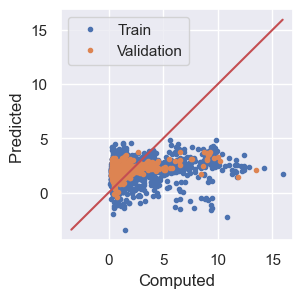

Epoch: 1, Train MAE: 2.1576, Val MAE: 1.7766
Epoch: 2, Train MAE: 1.9655, Val MAE: 1.7126
Epoch: 3, Train MAE: 1.9250, Val MAE: 1.6817
Epoch: 4, Train MAE: 1.8953, Val MAE: 1.6688
Epoch: 5, Train MAE: 1.8926, Val MAE: 1.6672
Epoch: 6, Train MAE: 1.8662, Val MAE: 1.6635
Epoch: 7, Train MAE: 1.8537, Val MAE: 1.6414
Epoch: 8, Train MAE: 1.8338, Val MAE: 1.6457
Epoch: 9, Train MAE: 1.8168, Val MAE: 1.6232
Epoch: 10, Train MAE: 1.8095, Val MAE: 1.6336


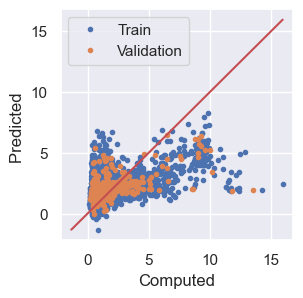

Epoch: 11, Train MAE: 1.8175, Val MAE: 1.6065
Epoch: 12, Train MAE: 1.7945, Val MAE: 1.5950
Epoch: 13, Train MAE: 1.7752, Val MAE: 1.6087
Epoch: 14, Train MAE: 1.7760, Val MAE: 1.5694
Epoch: 15, Train MAE: 1.7609, Val MAE: 1.5665
Epoch: 16, Train MAE: 1.7494, Val MAE: 1.5712
Epoch: 17, Train MAE: 1.7388, Val MAE: 1.5631
Epoch: 18, Train MAE: 1.7361, Val MAE: 1.5868
Epoch: 19, Train MAE: 1.7140, Val MAE: 1.5435
Epoch: 20, Train MAE: 1.7033, Val MAE: 1.5513


In [ ]:
# Train the model
train_losses = []
val_losses   = []
for epoch in np.arange(0, n_epochs):
    train_loss, train_predictions, train_ground_truths = clm.train(model, criterion, train_loader,
                                                                   target_factor,
                                                                   standardized_parameters['target_mean'],
                                                                   optimizer)
    val_loss,   val_predictions,   val_ground_truths   =  clm.test(model, criterion, val_loader,
                                                                   target_factor,
                                                                   standardized_parameters['target_mean'])

    # Convert to original units
    train_loss = np.sum(np.sqrt(train_loss) * target_factor)
    val_loss   = np.sum(np.sqrt(val_loss)   * target_factor)

    if epoch%5 == 0:
        epoch_plot_path = f'{timestamped_folder}/plot_epoch_{epoch}.png'
        cld.parity_plot(train=np.array([train_ground_truths, train_predictions]),
                        validation=np.array([val_ground_truths, val_predictions]),
                        save_to=epoch_plot_path,
                        title=f'Epoch {epoch}')
        print(f'Parity plot saved to: {epoch_plot_path}')
    
    # Append losses
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Check early stopping criteria
    early_stopping(val_loss, model)

    if early_stopping.early_stop:
        print('Early stopping')
        break

    print(f'Epoch: {epoch+1}, Train MAE: {train_loss:.4f}, Val MAE: {val_loss:.4f}')

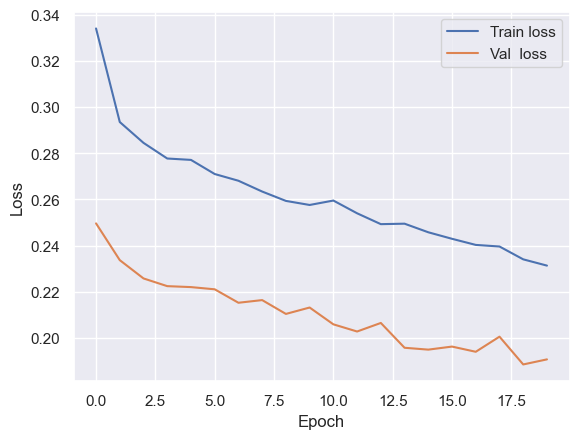

In [38]:
cld.losses_plot(train_losses=train_losses,
                val_losses=val_losses,
                to_log=True)

In [ ]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plot_files = sorted(glob.glob(f'{timestamped_folder}/plot_epoch_*.png'))
if not plot_files:
    raise FileNotFoundError(f'No se encontraron plots de epoch en {timestamped_folder}')

images = [mpimg.imread(path) for path in plot_files]
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(images[0])
ax.axis('off')
title = ax.text(0.5, 1.05, '', ha='center', va='bottom', transform=ax.transAxes, fontsize=14)


def update(frame):
    im.set_array(images[frame])
    epoch = os.path.basename(plot_files[frame]).split('_')[-1].split('.')[0]
    title.set_text(f'Epoch {epoch}')
    return im, title

anim = FuncAnimation(fig, update, frames=len(images), interval=800, blit=True)

animation_path = f'{timestamped_folder}/training_epochs_animation.gif'
try:
    anim.save(animation_path, writer='pillow', dpi=80)
    print(f'Animation saved to: {animation_path}')
except Exception as e:
    print('No se pudo guardar la animación GIF:', e)

HTML(anim.to_jshtml())

# Check test data

In [39]:
model = clm.load_model(n_node_features, dropout, device, model_name=files_names['model'], mode='eval')
model

DataParallel(
  (module): GCNN(
    (conv1): GraphConv(5, 512)
    (conv2): GraphConv(512, 512)
    (linconv1): Linear(in_features=512, out_features=64, bias=True)
    (linconv2): Linear(in_features=64, out_features=16, bias=True)
    (lin): Linear(in_features=16, out_features=1, bias=True)
  )
)

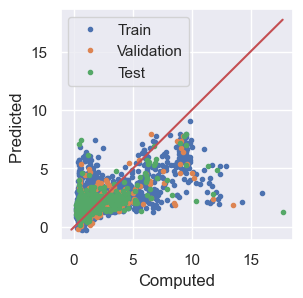

Train MAE: 1.6520, Val MAE: 1.5435, Test MAE: 1.7818


In [40]:
train_loss, train_predictions, train_ground_truths = clm.test(model, criterion, train_loader,
                                                              target_factor,
                                                              standardized_parameters['target_mean'])
val_loss,   val_predictions,   val_ground_truths   = clm.test(model, criterion, val_loader,
                                                              target_factor,
                                                              standardized_parameters['target_mean'])
test_loss,  test_predictions,  test_ground_truths  = clm.test(model, criterion, test_loader,
                                                              target_factor,
                                                              standardized_parameters['target_mean'])

# Pass to energy units (same as initial Fv)
train_loss = np.sum(np.sqrt(train_loss) * target_factor)
val_loss   = np.sum(np.sqrt(val_loss)   * target_factor)
test_loss  = np.sum(np.sqrt(test_loss)  * target_factor)

cld.parity_plot(train=np.array([train_ground_truths, train_predictions]),
                validation=np.array([val_ground_truths, val_predictions]),
                test=np.array([test_ground_truths, test_predictions]),
                save_to=f'{timestamped_folder}/GCNN-training.pdf')

print(f'Train MAE: {train_loss:.4f}, Val MAE: {val_loss:.4f}, Test MAE: {test_loss:.4f}')

In [41]:
import json

# Save detailed results to the timestamped model folder
results_data = {
    'timestamp': timestamp,
    'model_parameters': model_parameters,
    'training_history': {
        'train_losses': [float(loss) for loss in train_losses],
        'val_losses': [float(loss) for loss in val_losses],
        'epochs_completed': len(train_losses)
    },
    'final_metrics': {
        'train_mae': float(train_loss),
        'val_mae': float(val_loss),
        'test_mae': float(test_loss)
    },
    'predictions': {
        'train': {
            'predicted': train_predictions.tolist(),
            'actual': train_ground_truths.tolist()
        },
        'validation': {
            'predicted': val_predictions.tolist(),
            'actual': val_ground_truths.tolist()
        },
        'test': {
            'predicted': test_predictions.tolist(),
            'actual': test_ground_truths.tolist()
        }
    }
}

results_file = f'{timestamped_folder}/model_results_{timestamp}.json'
with open(results_file, 'w') as f:
    json.dump(results_data, f, indent=4)

print(f'Model results saved to: {results_file}')

Model results saved to: c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science\models\free-energies/results_20260427_194108/model_results_20260427_194108.json


In [42]:
import importlib
importlib.reload(cld)

<module 'libraries.dataset' from 'c:\\Users\\mateu\\Desktop\\gnn-material-science\\gnn-material-science\\gnn-material-science\\libraries\\dataset.py'>

Cargando resultados desde: c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science\models\free-energies/results_20260427_194108/model_results_20260427_194108.json

=== Curva de Aprendizaje (Loss) ===


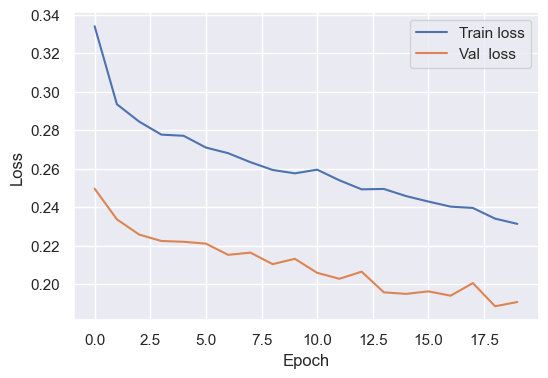

Loss chart saved to: c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science\models\free-energies/results_20260427_194108/training_loss_log.png


<Figure size 640x480 with 0 Axes>


=== Predicción vs Realidad (Conjunto de Test) ===
Prediction vs Real plot saved to: c:\Users\mateu\Desktop\gnn-material-science\gnn-material-science\gnn-material-science\models\free-energies/results_20260427_194108/prediction_vs_real.png


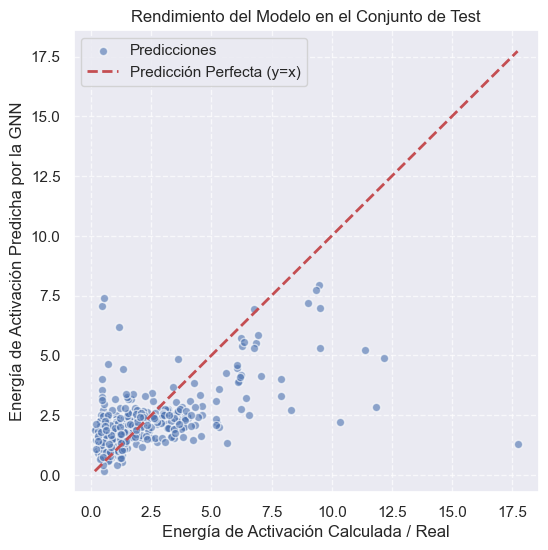


=== Métricas Finales (MAE) ===
Train MAE: 1.6520
Val MAE:   1.5435
Test MAE:  1.7818


In [44]:
import matplotlib.pyplot as plt

# 1. Definir la ruta del archivo (o usar la variable results_file si ya está en memoria)
results_file = f'{timestamped_folder}/model_results_{timestamp}.json'
print(f"Cargando resultados desde: {results_file}")

with open(results_file, 'r') as f:
    results_data = json.load(f)

# Extraer datos
train_losses = results_data['training_history']['train_losses']
val_losses = results_data['training_history']['val_losses']
predicted = results_data['predictions']['test']['predicted']
actual = results_data['predictions']['test']['actual']

# ==========================================
# 2. Visualización de la Curva de Aprendizaje
# ==========================================
print("\n=== Curva de Aprendizaje (Loss) ===")
# Esta función sí sabemos que existe y se llama así
plt.figure(figsize=(6, 4))
cld.losses_plot(train_losses, val_losses, to_log=True)
loss_plot_path = f'{timestamped_folder}/training_loss_log.png'
plt.savefig(loss_plot_path, dpi=300, bbox_inches='tight')
print(f'Loss chart saved to: {loss_plot_path}')
plt.show() # Forzamos a que se dibuje aquí para que no se mezcle con el siguiente

# ==========================================
# 3. Visualización de Predicción vs Realidad (Directo con Matplotlib)
# ==========================================
print("\n=== Predicción vs Realidad (Conjunto de Test) ===")
plt.figure(figsize=(6, 6))

# Dibujar los puntos
plt.scatter(actual, predicted, alpha=0.6, edgecolors='w', label='Predicciones')

# Dibujar la línea de predicción perfecta (y = x)
min_val = min(min(actual), min(predicted))
max_val = max(max(actual), max(predicted))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predicción Perfecta (y=x)')

# Formato del gráfico
plt.xlabel('Energía de Activación Calculada / Real')
plt.ylabel('Energía de Activación Predicha por la GNN')
plt.title('Rendimiento del Modelo en el Conjunto de Test')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
prediction_plot_path = f'{timestamped_folder}/prediction_vs_real.png'
plt.savefig(prediction_plot_path, dpi=300, bbox_inches='tight')
print(f'Prediction vs Real plot saved to: {prediction_plot_path}')
plt.show()

# ==========================================
# 4. Métricas
# ==========================================
print("\n=== Métricas Finales (MAE) ===")
print(f"Train MAE: {results_data['final_metrics']['train_mae']:.4f}")
print(f"Val MAE:   {results_data['final_metrics']['val_mae']:.4f}")
print(f"Test MAE:  {results_data['final_metrics']['test_mae']:.4f}")